# 06 — TabPFN (Tabular Foundation Model, 24h-Ahead PV Forecasting)

**Model:** TabPFN v2 — a tabular foundation model using in-context learning (no fine-tuning)  
**Key difference from TSFMs:** Uses meteorological variables as features (irradiance, temperature, etc.)  
rather than raw power history. Treats PV forecasting as a regression problem: `power = f(weather)`.  

**Motivation:** PV output is physically driven by meteorological conditions,
not by its own past values. Tabular foundation models may capture this better than time-series ones.

**Evaluation:**
- Primary: daytime samples (solar elevation > 5°)
- Secondary: all-hours
- Metrics: MAE, RMSE, nRMSE, train time, inference time per 24h window

**Install:**
```bash
pip install tabpfn
```

**Run `01_data_processing.ipynb` first** to generate `data/dataset.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import os
from tqdm import tqdm
import importlib.metadata

from tabpfn_client import TabPFNRegressor, set_access_token
set_access_token("TOKEN_HERE") # Sign up here : https://ux.priorlabs.ai/home and get token, I have removed mine as repo is public

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)

# ── Config ──
PREDICTION_LENGTH = 96     # 24h at 15-min resolution
STRIDE            = 96     # step 1 day at a time
MAX_TRAIN_SAMPLES = 3000   # TabPFN works best with small N; subsample if larger
MAX_WINDOWS       = None   # set e.g. 10 for a quick smoke-test
MODEL_NAME        = 'TabPFN'
RANDOM_STATE      = 321

print(f'tabpfn version : {importlib.metadata.version("tabpfn")}')

tabpfn version : 8.0.8


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}
df_full = df.resample('15min', closed='left', label='left').agg(agg)
df_full['power'] = df_full['power'].fillna(0).clip(lower=0)
wx_cols = [c for c in df_full.columns if c != 'power']
df_full[wx_cols] = df_full[wx_cols].ffill().fillna(0)
df_full['solar_elevation'] = (90 - df_full['sun_zenith']).clip(lower=0)

print(f'15-min grid shape: {df_full.shape}')
print(f'Range: {df_full.index.min()} → {df_full.index.max()}')

15-min grid shape: (171139, 8)
Range: 2018-04-17 07:15:00 → 2023-03-04 23:45:00


## 2. Feature Engineering

Same 10 features as the LightGBM/MLP baselines:
6 meteorological variables + 4 cyclical time encodings.

In [3]:
def make_features(df):
    df = df.copy()
    hour = df.index.hour + df.index.minute / 60
    doy  = df.index.dayofyear
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    df['doy_sin']  = np.sin(2 * np.pi * doy  / 365)
    df['doy_cos']  = np.cos(2 * np.pi * doy  / 365)
    return df

FEATURE_COLS = [
    'global_irradiance', 'direct_irradiance', 'diffuse_irradiance',
    'temperature', 'sun_zenith', 'sun_azimuth',
    'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
]

df_feat = make_features(df_full)

# ── Same train/test split as baselines ──
train_mask = df_feat.index < pd.Timestamp('2020-01-01')
test_mask  = (df_feat.index >= pd.Timestamp('2020-01-01')) & \
             (df_feat.index <= pd.Timestamp('2020-08-01'))

X_train_full = df_feat.loc[train_mask, FEATURE_COLS].values.astype(np.float32)
y_train_full = df_feat.loc[train_mask, 'power'].values.astype(np.float32)
X_test       = df_feat.loc[test_mask,  FEATURE_COLS].values.astype(np.float32)
y_test       = df_feat.loc[test_mask,  'power'].values.astype(np.float32)
ts_test      = df_feat.index[test_mask]
solar_test   = df_feat.loc[test_mask, 'solar_elevation'].values

print(f'Train samples : {len(X_train_full):,}')
print(f'Test  samples : {len(X_test):,}')
print(f'Features      : {FEATURE_COLS}')

Train samples : 59,875
Test  samples : 20,449
Features      : ['global_irradiance', 'direct_irradiance', 'diffuse_irradiance', 'temperature', 'sun_zenith', 'sun_azimuth', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


## 3. Fit TabPFN

TabPFN is a **prior-fitted network** — pre-trained on synthetic datasets generated from a Bayesian prior.
It uses **in-context learning**: the training set is passed as context at inference time (no gradient updates).

Because the context is passed at each forward pass, TabPFN works best with ≤ 3000 training samples.
We subsample the full training set; stratified on daytime/nighttime to keep the distribution balanced.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)

if len(X_train_full) > MAX_TRAIN_SAMPLES:
    # Stratified subsample: half daytime, half nighttime (by irradiance)
    day_idx   = np.where(df_feat.loc[train_mask, 'global_irradiance'].values > 0)[0]
    night_idx = np.where(df_feat.loc[train_mask, 'global_irradiance'].values == 0)[0]
    n_day   = min(MAX_TRAIN_SAMPLES // 2, len(day_idx))
    n_night = MAX_TRAIN_SAMPLES - n_day
    sel = np.concatenate([
        rng.choice(day_idx,   n_day,   replace=False),
        rng.choice(night_idx, n_night, replace=False),
    ])
    X_train = X_train_full[sel]
    y_train = y_train_full[sel]
    print(f'Subsampled training: {len(X_train)} samples '
          f'({n_day} daytime + {n_night} nighttime)')
else:
    X_train = X_train_full
    y_train = y_train_full
    print(f'Using full training set: {len(X_train)} samples')

print('\nFitting TabPFN ...')
t0 = time.time()
tabpfn = TabPFNRegressor()
tabpfn.fit(X_train, y_train)
train_time = time.time() - t0
print(f'TabPFN fitted in {train_time:.2f}s')

Subsampled training: 3000 samples (1500 daytime + 1500 nighttime)

Fitting TabPFN ...
00:09 Fitting... Done!
TabPFN fitted in 11.58s


## 4. Rolling 24h-Ahead Evaluation

For each day in the test period: predict the next 96 steps (24h) using meteorological features.
Measure inference time per 24h window.

In [7]:
test_start_idx = 0
test_end_idx   = len(X_test)
start_positions = list(range(test_start_idx, test_end_idx - PREDICTION_LENGTH + 1, STRIDE))
if MAX_WINDOWS:
    start_positions = start_positions[:MAX_WINDOWS]

n = len(start_positions)
all_preds   = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_actuals = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_ts      = []
infer_times = []

for w, i in enumerate(tqdm(start_positions, desc='TabPFN rolling eval')):
    X_window = X_test[i : i + PREDICTION_LENGTH]
    y_window = y_test[i : i + PREDICTION_LENGTH]
    ts       = ts_test[i : i + PREDICTION_LENGTH]

    t0   = time.time()
    pred = tabpfn.predict(X_window)
    infer_times.append(time.time() - t0)

    all_preds[w]   = np.clip(pred, 0, None)
    all_actuals[w] = y_window
    all_ts.append(ts)

print(f'Done. Avg inference time: {np.mean(infer_times):.3f}s per 24h window')

TabPFN rolling eval:   0%|                              | 0/213 [00:00<?, ?it/s]

00:01 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!


TabPFN rolling eval:   0%|                      | 1/213 [00:03<13:02,  3.69s/it]

...

00:00 Predicting... |

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!


TabPFN rolling eval: 100%|████████████████████| 213/213 [09:10<00:00,  2.58s/it]

Done. Avg inference time: 2.581s per 24h window


## 5. Metrics — Daytime & All-Hours

In [8]:
preds_flat   = np.clip(all_preds.ravel(), 0, None)
actuals_flat = all_actuals.ravel()
ts_flat      = pd.DatetimeIndex(np.concatenate([t.values for t in all_ts]))

solar_elev = df_feat['solar_elevation'].reindex(ts_flat).values
day_mask   = solar_elev > 5

def metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.max()
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return mae, rmse, nrmse

print(f'\n=== {MODEL_NAME} ===')
mae_d, rmse_d, nrmse_d = metrics(actuals_flat[day_mask], preds_flat[day_mask], 'Daytime (solar_elev > 5°)')
mae_a, rmse_a, nrmse_a = metrics(actuals_flat,           preds_flat,           'All-hours')

avg_infer = np.mean(infer_times)
print(f'\nTrain time            : {train_time:.2f}s')
print(f'Avg inference / 24h   : {avg_infer:.3f}s')
print(f'Daytime samples       : {day_mask.sum()} / {len(day_mask)}')


=== TabPFN ===
[Daytime (solar_elev > 5°)]  MAE=0.0457  RMSE=0.0893  nRMSE=0.1039
[All-hours]  MAE=0.0223  RMSE=0.0623  nRMSE=0.0724

Train time            : 11.58s
Avg inference / 24h   : 2.581s
Daytime samples       : 9930 / 20448


## 6. Plots

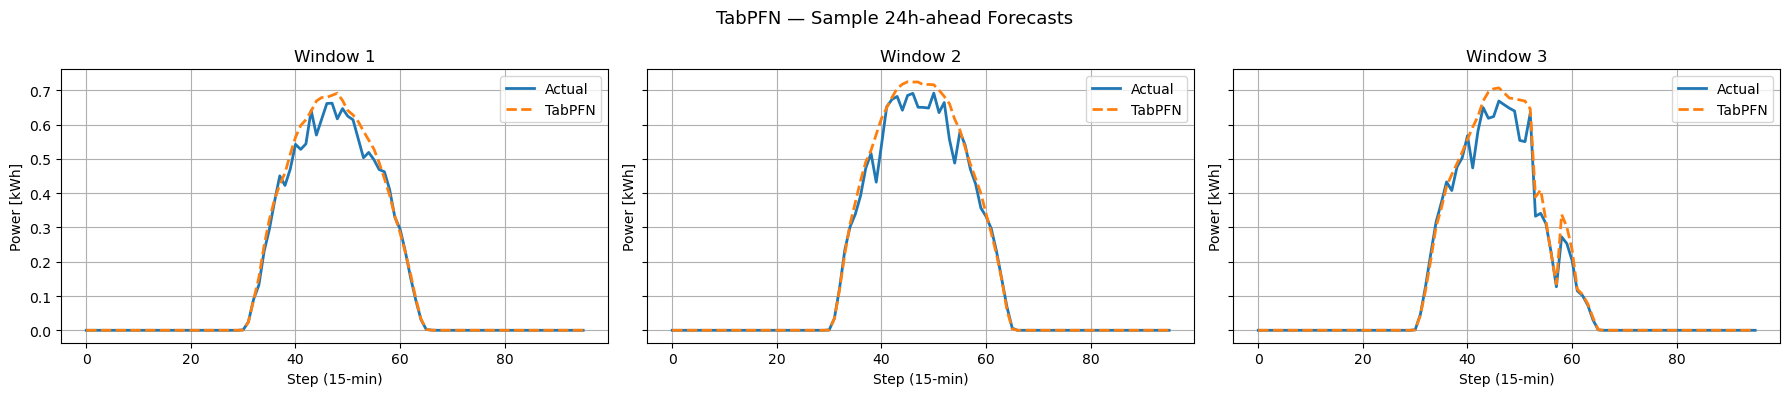

Saved → ../figure/06_tabpfn_sample_forecasts.png


In [9]:
# ── Sample 24h forecast windows ──
sunny_windows = [w for w in range(n) if all_actuals[w].max() > 0.01][:3]

fig, axes = plt.subplots(1, len(sunny_windows), figsize=(6 * len(sunny_windows), 4), sharey=True)
if len(sunny_windows) == 1:
    axes = [axes]

for ax, w in zip(axes, sunny_windows):
    ax.plot(all_actuals[w], label='Actual', linewidth=2)
    ax.plot(all_preds[w],   label='TabPFN', linewidth=2, linestyle='--')
    ax.set_title(f'Window {w+1}')
    ax.set_xlabel('Step (15-min)'); ax.set_ylabel('Power [kWh]')
    ax.legend(); ax.grid(True)

plt.suptitle(f'{MODEL_NAME} — Sample 24h-ahead Forecasts', fontsize=13)
plt.tight_layout()
plt.savefig('../figure/06_tabpfn_sample_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/06_tabpfn_sample_forecasts.png')

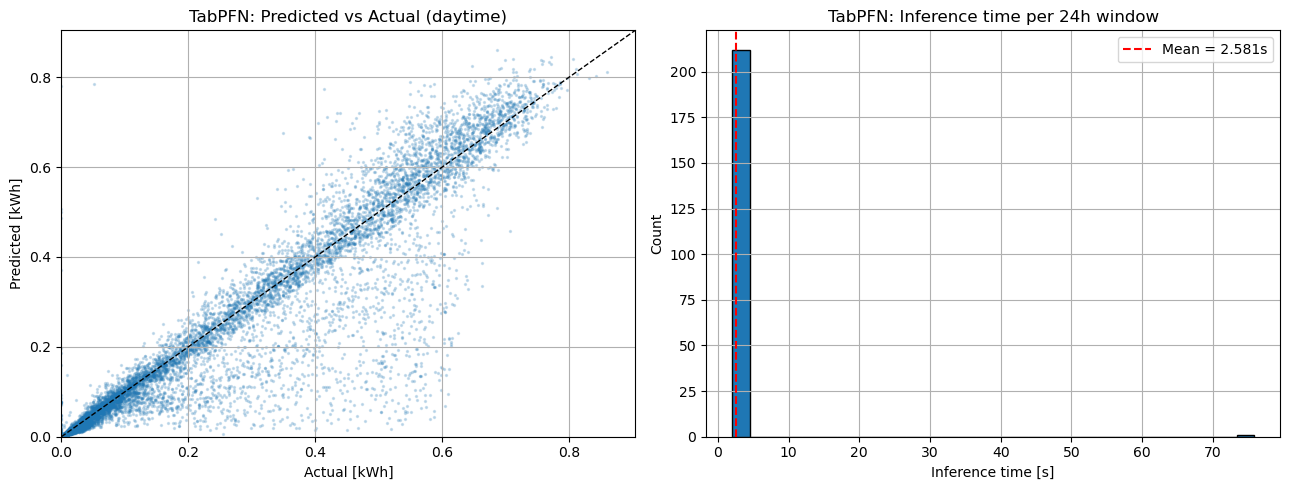

Saved → ../figure/06_tabpfn_eval.png


In [10]:
# ── Scatter + inference time ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(actuals_flat[day_mask].max(), preds_flat[day_mask].max()) * 1.05
axes[0].scatter(actuals_flat[day_mask], preds_flat[day_mask], s=2, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
axes[0].set_title(f'{MODEL_NAME}: Predicted vs Actual (daytime)')
axes[0].grid(True)

axes[1].hist(infer_times, bins=30, edgecolor='black')
axes[1].axvline(avg_infer, color='red', linestyle='--', label=f'Mean = {avg_infer:.3f}s')
axes[1].set_xlabel('Inference time [s]'); axes[1].set_ylabel('Count')
axes[1].set_title(f'{MODEL_NAME}: Inference time per 24h window')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('../figure/06_tabpfn_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/06_tabpfn_eval.png')

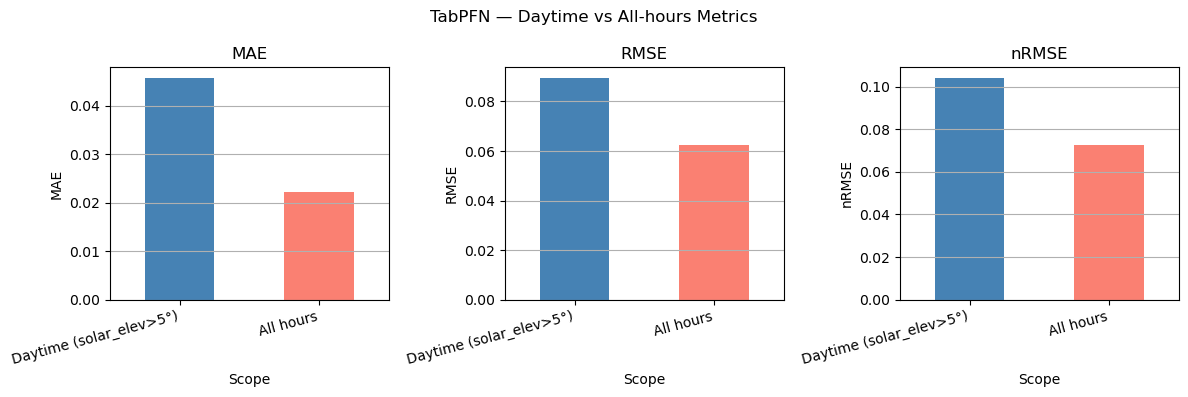

Saved → ../figure/06_tabpfn_daytime_vs_allhours.png


In [11]:
# ── Daytime vs all-hours bar chart ──
metrics_df = pd.DataFrame({
    'Scope': ['Daytime (solar_elev>5°)', 'All hours'],
    'MAE':   [mae_d,   mae_a],
    'RMSE':  [rmse_d,  rmse_a],
    'nRMSE': [nrmse_d, nrmse_a],
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'nRMSE']):
    metrics_df.set_index('Scope')[col].plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(col); ax.set_ylabel(col); ax.grid(axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle(f'{MODEL_NAME} — Daytime vs All-hours Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('../figure/06_tabpfn_daytime_vs_allhours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/06_tabpfn_daytime_vs_allhours.png')

## 7. Save Results

In [12]:
pd.DataFrame({
    'timestamp'  : ts_flat,
    'actual'     : actuals_flat,
    'tabpfn'     : preds_flat,
    'solar_elev' : solar_elev,
    'daytime'    : day_mask,
}).to_pickle('../results/tabpfn_predictions.pkl')
print('Saved → ../results/tabpfn_predictions.pkl')

Saved → ../results/tabpfn_predictions.pkl


In [13]:
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {'Model': MODEL_NAME,                'MAE': mae_d, 'RMSE': rmse_d, 'nRMSE': nrmse_d,
     'Train Time': train_time, 'Inference Time': avg_infer},
    {'Model': f'{MODEL_NAME} (all-hrs)', 'MAE': mae_a, 'RMSE': rmse_a, 'nRMSE': nrmse_a,
     'Train Time': train_time, 'Inference Time': avg_infer},
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

            Model      MAE     RMSE    nRMSE  Train Time  Inference Time
         LightGBM 0.021175 0.034823 0.040512    0.196141        0.014383
 LightGBM (tuned) 0.020895 0.034539 0.040182   66.418172        0.037487
              MLP 0.020945 0.034464 0.040095    2.954158        0.017441
          Chronos 0.164308 0.231903 0.269790    0.000000        1.622153
Chronos (all-hrs) 0.104663 0.188088 0.218817    0.000000        1.622153
          TimesFM 0.124079 0.178613 0.207794    0.000000        0.077968
TimesFM (all-hrs) 0.062519 0.126753 0.147461    0.000000        0.077968
           Moirai 0.222258 0.326228 0.379526    0.000000        0.017504
 Moirai (all-hrs) 0.247542 0.430665 0.501025    0.000000        0.017504
           TabPFN 0.045660 0.089320 0.103913   11.576127        2.581436
 TabPFN (all-hrs) 0.022287 0.062252 0.072422   11.576127        2.581436
